In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/home/brian/Documents/projects/applied-machine-learning/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/brian/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
import os
# list files in the path
print(os.listdir(path))

['creditcard.csv']


In [3]:
creditcard_path = os.path.join(path, 'creditcard.csv')
data = pd.read_csv(creditcard_path)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Examine features
print(data.columns)
# Examine the class distribution
print("\nClass distribution:")
print(data['Class'].value_counts())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


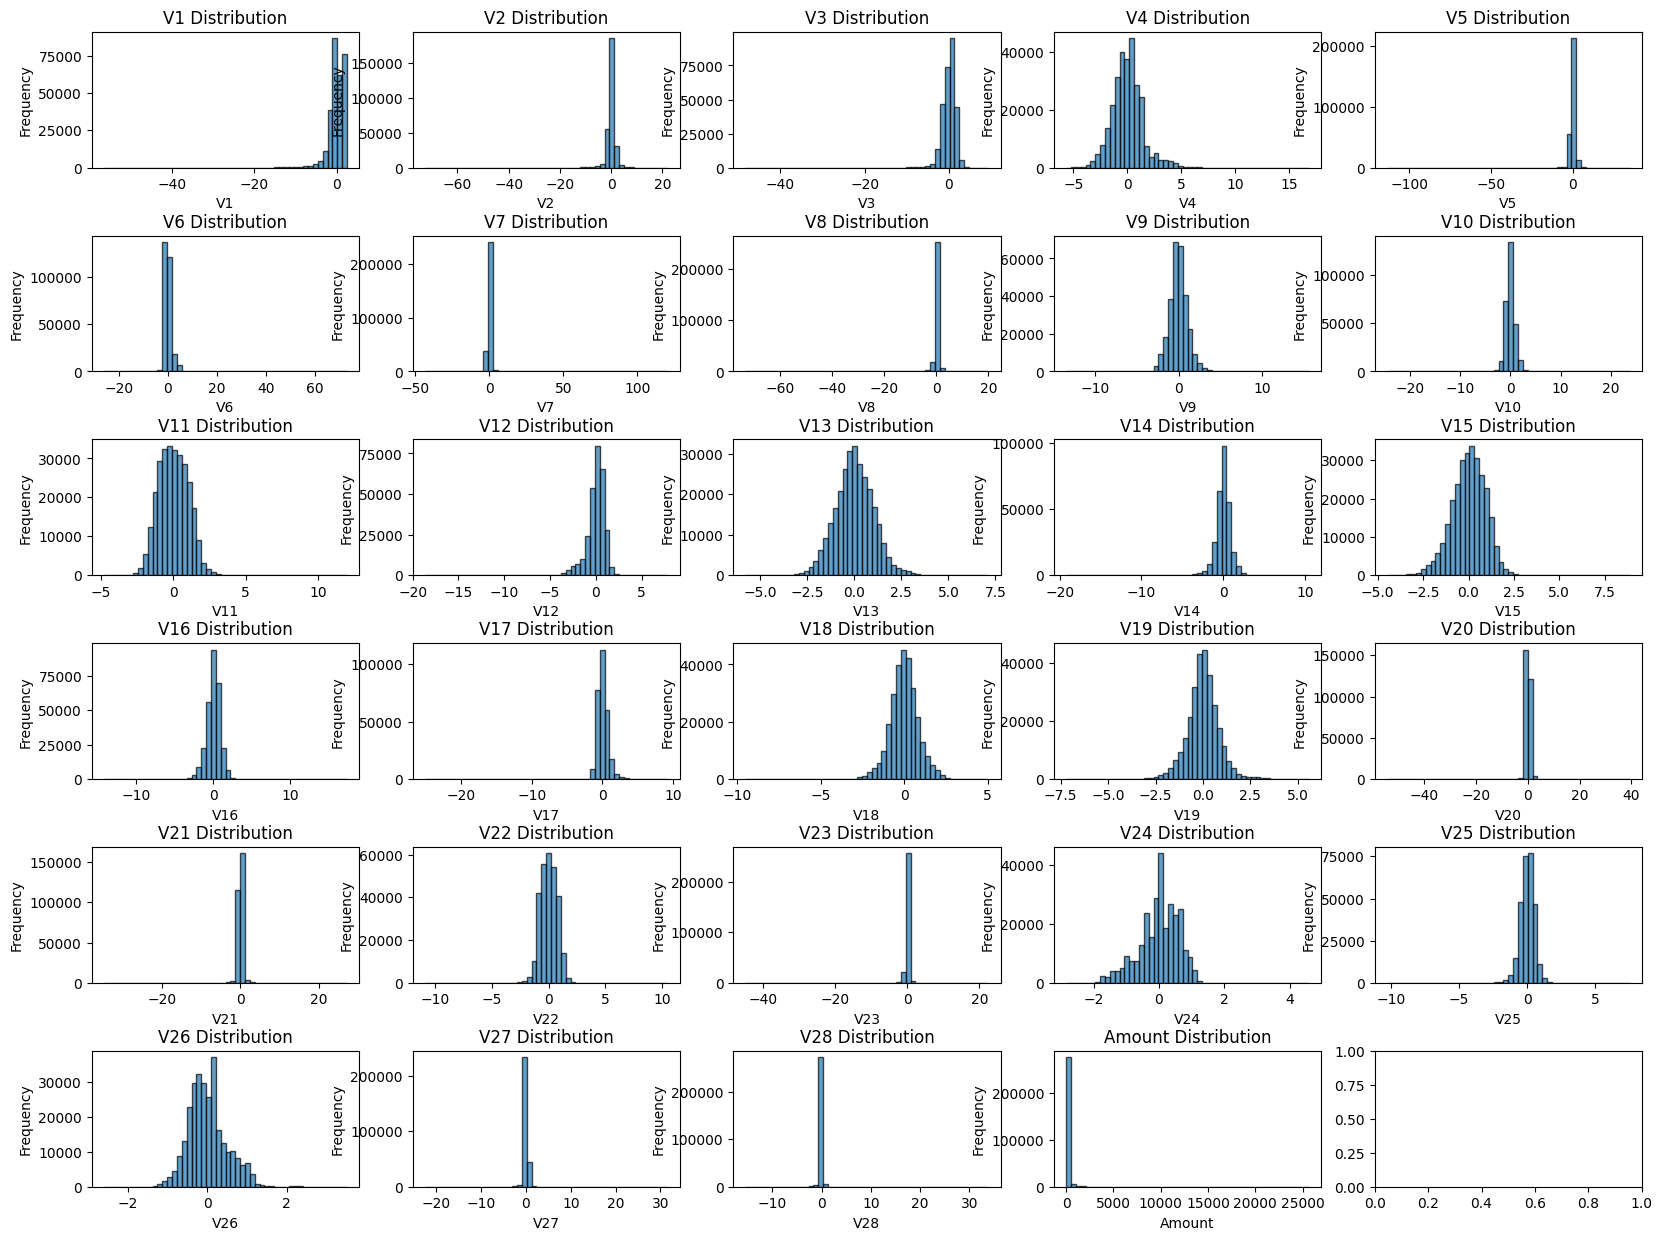


Summary Statistics:
                 V1            V2            V3            V4            V5  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15  1.021879e-15   
std    1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min   -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%    1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15  2.238554e-15   
std    1.332271e+00  1.237094e

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get all feature columns (excluding Time and Class)
feature_cols = [col for col in data.columns if col not in ['Time', 'Class']]

# Create histograms for all features
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 15))
axes = axes.flatten()

plt.subplots_adjust(hspace=0.5)

for idx, col in enumerate(feature_cols):
    axes[idx].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.show()

print("\nSummary Statistics:")
print(data[feature_cols].describe())



# Evaluation Metric

Since most transactions are *not* fraud, if we had a model that guessed non-fraud for all transactions, it would have a very high accuracy. For this reason, we need a different metric. In this case, we want to use Recall, Precision, and F1-score. I'll primarily focus on F1-score to get a more balanced look at precision and recall, but if we were trying to minimize false fraud alerts, we could focus more on precision so as not to disrupt regular card users, or focus on recall if catching all frauds was the priority.

# Question 3 - Standarization or Normalization

Looking at our data the main features (V1-V28) are already standarized. To finish pre-processing this dataset we can drop the time column as this is not a predictive feature here, and we can standarize the amount column, since that is the only column that is not currently standarized. The classifiers we're using (SVC and MLPClassifier) are sensitive to feature scales. Features with larger ranges can dominate the learning process and impact model performance. By standardizing Amount to match the scale of V1-V28, we can be sure all features contribute equally to the model.

In [6]:
from sklearn.preprocessing import StandardScaler

preprocessed_data = data.copy()
preprocessed_data['Amount'] = StandardScaler().fit_transform(preprocessed_data[['Amount']])
preprocessed_data = preprocessed_data.drop(columns=['Time'])

preprocessed_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [7]:
from sklearn.model_selection import train_test_split

X = preprocessed_data.drop(columns=['Class'])
y = preprocessed_data['Class']

# 50/50 split on data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

X_train.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
126247,1.149907,0.020216,-0.095297,1.029788,0.426260,0.809204,-0.037762,0.211147,0.143879,0.039982,...,-0.100386,-0.112573,-0.191762,-0.240985,-1.145808,0.770264,-0.259460,0.027821,-0.001762,-0.208419
42508,1.156724,0.411155,0.915068,2.512448,-0.496515,-0.436129,-0.141861,0.028122,-0.384754,0.700740,...,-0.214952,-0.106942,-0.440053,0.082861,0.325173,0.251069,-0.126533,-0.005867,0.028982,-0.307131
122710,1.155467,-0.082742,0.772878,0.406323,-0.470132,0.248047,-0.550436,0.263281,0.199039,0.051862,...,-0.116218,-0.031563,-0.112790,0.071490,-0.299515,0.087012,0.246823,0.002631,0.009327,-0.317287
143965,1.237639,0.313789,0.194803,0.497667,-0.132052,-0.554997,-0.007754,-0.049065,-0.240606,-0.120077,...,-0.044824,-0.255061,-0.758196,0.073909,-0.030451,0.238024,0.096570,-0.025675,0.017739,-0.348072
100207,1.086681,0.552043,-0.224936,2.518481,0.375527,-0.262240,0.315264,-0.076407,-0.699289,0.187612,...,0.038884,-0.269292,-1.025118,-0.098165,-0.595574,0.419725,-0.142003,-0.017693,0.054833,-0.018869


Classifiers without regularization or tree pruning
- svc
- decision tree
- MLP classifier
- Random Forest

In [8]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Train the SVC model
svc_model = SVC(kernel='rbf', C=1, gamma='auto')
svc_model.fit(X_train, y_train)

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

mlp_classifier = MLPClassifier(random_state=42)
mlp_classifier.fit(X_train, y_train)

random_forest_model = RandomForestClassifier(random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
# report model performance

def report_model_performance(model, X_test, y_test, feature_cols):
    predictions = model.predict(X_test)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    print(f"Model: {model.__class__.__name__}")
    print(f"Precision: {precision}, Recall: {recall}, F1-score: {f1}")
    return precision, recall, f1


report_model_performance(svc_model, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(decision_tree_model, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(mlp_classifier, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(random_forest_model, X_test, y_test, feature_cols)


Model: SVC
Precision: 0.9743589743589743, Recall: 0.6178861788617886, F1-score: 0.7562189054726368
----------------------------------------------------------------------------------------------------
Model: DecisionTreeClassifier
Precision: 0.7410358565737052, Recall: 0.7560975609756098, F1-score: 0.7484909456740443
----------------------------------------------------------------------------------------------------
Model: MLPClassifier
Precision: 0.8786407766990292, Recall: 0.7357723577235772, F1-score: 0.8008849557522124
----------------------------------------------------------------------------------------------------
Model: RandomForestClassifier
Precision: 0.9633507853403142, Recall: 0.7479674796747967, F1-score: 0.8421052631578947


(0.9633507853403142, 0.7479674796747967, 0.8421052631578947)

In [ ]:
from sklearn.model_selection import GridSearchCV

# add regularization and/or tree pruning
# preform grid search to find best parameters for decision tree

model = DecisionTreeClassifier(random_state=42)
 
tree_params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}


tree_grid_search = GridSearchCV(estimator=decision_tree_model, param_grid=tree_params, cv=5, scoring='f1', n_jobs=-1)
tree_grid_search.fit(X_train, y_train)


Model: DecisionTreeClassifier
Precision: 0.8761467889908257, Recall: 0.7764227642276422, F1-score: 0.8232758620689655


(0.8761467889908257, 0.7764227642276422, 0.8232758620689655)

In [11]:
print('model params:')
print(tree_grid_search.best_estimator_.get_params())

# report model performance

report_model_performance(tree_grid_search.best_estimator_, X_test, y_test, feature_cols)


model params:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Model: DecisionTreeClassifier
Precision: 0.8761467889908257, Recall: 0.7764227642276422, F1-score: 0.8232758620689655


(0.8761467889908257, 0.7764227642276422, 0.8232758620689655)

In [12]:
# MLP Classifier

model = MLPClassifier(random_state=42)

mlp_params = {
    'hidden_layer_sizes': [(30,), (50,), (100,)],
    'activation': ['relu', 'tanh', 'logistic'],
    'alpha': [0.0001, 0.001, 0.01],
}

mlp_grid_search = GridSearchCV(estimator=model, param_grid=mlp_params, cv=5, scoring='f1', n_jobs=-1)
mlp_grid_search.fit(X_train, y_train)


,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['relu', 'tanh', ...], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(30,), (50,), ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100,)"


In [13]:
print('model params:')
print(mlp_grid_search.best_estimator_.get_params())

report_model_performance(mlp_grid_search.best_estimator_, X_test, y_test, feature_cols)


model params:
{'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Model: MLPClassifier
Precision: 0.9753086419753086, Recall: 0.6422764227642277, F1-score: 0.7745098039215687


(0.9753086419753086, 0.6422764227642277, 0.7745098039215687)

In [ ]:
# svc classifier

svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'sigmoid'],
    'gamma': ['auto', 'scale'],
}

svc_grid_search = GridSearchCV(estimator=svc_model, param_grid=svc_params, cv=5, scoring='f1', n_jobs=-1)
svc_grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:

print('model params:')
print(svc_grid_search.best_estimator_.get_params())

report_model_performance(svc_grid_search.best_estimator_, X_test, y_test, feature_cols)